### GJ-3090b JWST Spectrum



In [ ]:
from POSEIDON.core import wl_grid_constant_R
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_J, R_E, M_E
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.58      # Minimum wavelength (um)
wl_max = 5.30      # Maximum wavelength (um)
R = 20000          # Spectral resolution of grid      

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.4555*R_Sun    # Stellar radius (m)
T_s = 3575.0          # Stellar effective temperature (K)
err_T_s = 53          # Value in ExoMast
Met_s = 0.3           # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.778       # Stellar log surface gravity (log10(cm/s^2) by convention)
err_log_g_s = 0.026

# Create the stellar object
#star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
                   #stellar_grid = 'phoenix', wl = wl)
star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
                  stellar_grid = 'phoenix', interp_backend = 'pymsg', wl = wl)

#***** Define planet properties *****#

planet_name = 'TOI-1685b'  # Planet name used for plots, output files etc.

R_p = 1.468*R_E     # Planetary radius (m)
M_p = 3.03*M_E      # Planet mass
T_eq = 1062         # Equilibrium temperature (K)
d = 37.6513*pc      # Distance to system (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, d = d)

Load data

In [ ]:
from POSEIDON.core import load_data
from POSEIDON.visuals import plot_data
import numpy as np

#***** Specify data location and instruments *****#

if ('NIRISS' in data_included):
    datasets.append(planet_name + '_NIRISS_SOSS_Ord2_ExoTEP_R100.dat')
    datasets.append(planet_name + '_NIRISS_SOSS_Ord1_ExoTEP_R100.dat')
    instruments.append('JWST_NIRISS_SOSS_Ord2')
    instruments.append('JWST_NIRISS_SOSS_Ord1')

if ('NIRSpec' in data_included):
    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_ExoTEP_R100.dat')
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_ExoTEP_R100.dat')
    instruments.append('JWST_NIRSpec_G395H_NRS1')
    instruments.append('JWST_NIRSpec_G395H_NRS2')

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

Old data

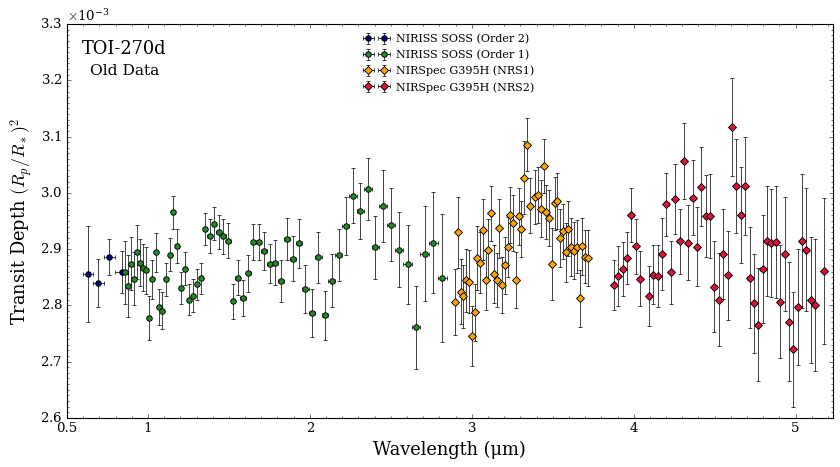

In [ ]:
fig_data = plot_data(data, planet_name, plt_label = 'Old Data',
                     data_labels = ['NIRISS SOSS (Order 2)', 'NIRISS SOSS (Order 1)',
                                    'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)'],
                     data_colour_list = ['navy', 'forestgreen',
                                         'orange', 'crimson'],
                     data_marker_list = ['o', 'o', 'D', 'D'],
                     data_marker_size_list = [5, 5, 4.5, 4.5],
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                    )

New data

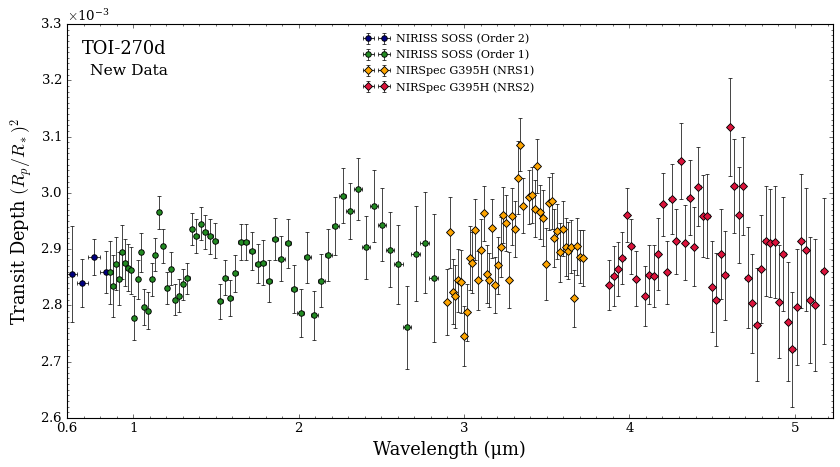

In [ ]:
fig_data = plot_data(data, planet_name, plt_label = 'New Data',
                     data_labels = ['NIRISS SOSS (Order 2)', 'NIRISS SOSS (Order 1)',
                                    'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)'],
                     data_colour_list = ['navy', 'forestgreen',
                                         'orange', 'crimson'],
                     data_marker_list = ['o', 'o', 'D', 'D'],
                     data_marker_size_list = [5, 5, 4.5, 4.5],
                     wl_min = 0.6,
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                     )

Comparison

In [ ]:
#***** Specify data location and instruments *****#

data_dir = './data/' + planet_name

datasets = [planet_name + '_NIRISS_SOSS_Ord2.dat',
            planet_name + '_NIRISS_SOSS_Ord1.dat',
            planet_name + '_NIRISS_SOSS_Ord2_old.dat',
            planet_name + '_NIRISS_SOSS_Ord1_old.dat',
            ]

instruments = ['JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1',
               'JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1',
              ]

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

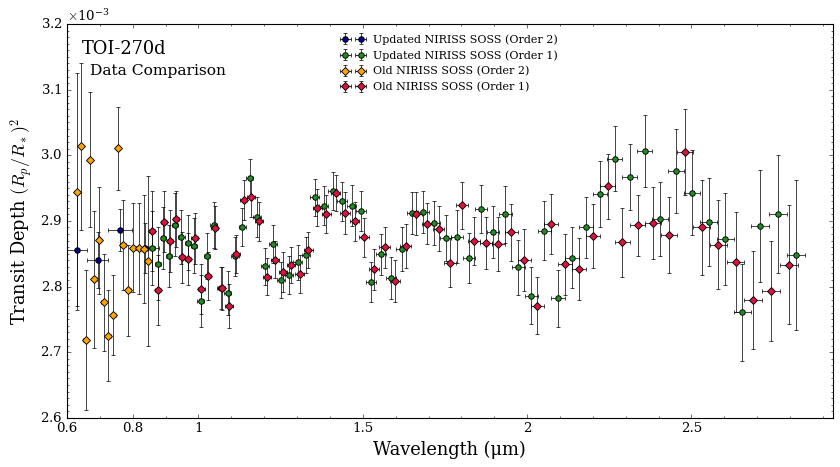

In [ ]:
fig_data = plot_data(data, planet_name, plt_label = 'Data Comparison',
                     data_labels = ['Updated NIRISS SOSS (Order 2)', 'Updated NIRISS SOSS (Order 1)',
                                    'Old NIRISS SOSS (Order 2)', 'Old NIRISS SOSS (Order 1)',],
                     data_colour_list = ['navy', 'forestgreen',
                                         'orange', 'crimson'],
                     data_marker_list = ['o', 'o', 'D', 'D'],
                     data_marker_size_list = [5, 5, 4.5, 4.5],
                     wl_min = 0.6, y_min = 2.6e-3,
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                     )

# Retrieval results plots (Start here)

In [1]:
from POSEIDON.constants import R_Sun, R_J, R_E, M_E
from POSEIDON.core import create_star, create_planet, load_data, define_model, \
                          wl_grid_constant_R, read_opacities, compute_spectrum
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, \
                             plot_collection, write_spectrum
from POSEIDON.corner import generate_cornerplot
from POSEIDON.visuals import plot_spectra_retrieved, plot_PT_retrieved, plot_histograms
from POSEIDON.retrieval import get_retrieved_atmosphere, Bayesian_model_comparison
from POSEIDON.stellar import stellar_contamination


import numpy as np
from spectres import spectres

from scipy.constants import parsec as pc

# data_included = 'NIRISS_Visit1_exoTEDRF_R100'
data_included = 'joint_NIRISS_NIRSpec_Offset_Stacked_ExoTEP_R100'

model_name = 'multigas_TS_2000_' + data_included

bulk_species = ['H2', 'He']     # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4', 'CO', 'NH3', 'CO2', 'SO2']

stellar_contam = None
if '_OS_' in model_name:
    stellar_contam = 'one_spot'
elif '_OSfree_' in model_name:
    stellar_contam = 'one_spot_free_log_g'
if '_TS_' in model_name:
    stellar_contam = 'two_spots'
elif '_TSfree_' in model_name:
    stellar_contam = 'two_spots_free_log_g'

#***** Model wavelength grid *****#

if 'joint' in model_name:
    wl_min = 0.5      # Minimum wavelength (um)
    wl_max = 5.4      # Maximum wavelength (um)
elif 'NIRSpec' in data_included:
    wl_min = 2.7
    wl_max = 5.4
elif 'NIRISS' in data_included:
    wl_min = 0.5
    wl_max = 2.9
R = 20000          # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.4555*R_Sun    # Stellar radius (m)
T_s = 3575.0          # Stellar effective temperature (K)
err_T_s = 53          # Value in ExoMast
Met_s = 0.3           # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.778       # Stellar log surface gravity (log10(cm/s^2) by convention)
err_log_g_s = 0.026

# Create the stellar object
#star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
                   #stellar_grid = 'phoenix', wl = wl)
star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
                  stellar_grid = 'phoenix', interp_backend = 'pymsg', wl = wl)
#star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
#                   log_g_error = err_log_g_s, # stellar_grid = 'cbk04')
#                   stellar_grid = 'phoenix', interp_backend = 'pymsg',
#                   wl = wl)

#***** Define planet properties *****#

planet_name = 'TOI-1685b'  # Planet name used for plots, output files etc.

R_p = 1.468*R_E     # Planetary radius (m)
M_p = 3.03*M_E      # Planet mass
T_eq = 1062         # Equilibrium temperature (K)
d = 37.6513*pc      # Distance to system (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, d = d)

#***** Specify data location and instruments *****#

data_dir = './data/' + planet_name
#data_dir = './data/' + planet_name + '/Old Data'

datasets = []
instruments = []

if ('NIRISS' in data_included):
    datasets.append(planet_name + '_NIRISS_SOSS_Ord2_ExoTEP_R100.dat')
    datasets.append(planet_name + '_NIRISS_SOSS_Ord1_ExoTEP_R100.dat')
    instruments.append('JWST_NIRISS_SOSS_Ord2')
    instruments.append('JWST_NIRISS_SOSS_Ord1')

if ('NIRSpec' in data_included):
    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_ExoTEP_R100.dat')
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_ExoTEP_R100.dat')
    instruments.append('JWST_NIRSpec_G395H_NRS1')
    instruments.append('JWST_NIRSpec_G395H_NRS2')


data = load_data(data_dir, datasets, instruments, wl,
                 offset_1_datasets = [datasets[2], datasets[3]],
                #  offset_2_datasets = [datasets[4], datasets[5]],
                #  offset_3_datasets = [datasets[6], datasets[7]],
                 )

# data = load_data(data_dir, datasets, instruments, wl,
#                  offset_1_datasets = [datasets[2], datasets[3]],
#                  )

# Read retrieval results

In [2]:
#***** Define model *****#

cloud_model = 'MacMad17'
surface = False
disable_atmosphere = False
if 'flat_' in model_name:
    param_species = []
    surface = True
    disable_atmosphere = True

cloud_type = 'deck_haze'
if 'no-haze_' in model_name:
    cloud_type = 'deck'

if 'clear_' in model_name:
    cloud_model = 'cloud-free'

# Create the model object
model = define_model(model_name, bulk_species, param_species, 
                     PT_profile = 'isotherm', cloud_model = cloud_model,
                     cloud_type = cloud_type, cloud_dim = 1,
                     radius_unit = 'R_E', surface = surface,
                     disable_atmosphere = disable_atmosphere,
                     stellar_contam = stellar_contam, 
                     offsets_applied = 'single_dataset'
                     )

# Create composite spectra objects for plotting
spectra_median = []
spectra_low2 = []
spectra_low1 = []
spectra_high1 = []
spectra_high2 = []

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Add retrieved spectra to composite objects
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1) 
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2) 
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1) 
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Best-Fitting Model

In [3]:
#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # Same as prior range for T
T_fine_max = 1000    # Same as prior range for T
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-7   # 10 nbar
P_max = 100       # 10 bar
N_layers = 100   # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 10.0   # Retrieved R_p_ref parameter will be the radius at 10 bar

# Pre-interpolate the opacities
# opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)


In [ ]:
# #***** Make Best-fitting Model *****#

# # REPLACE WITH YOUR BEST-FITTING VALUES
# R_p_ref = 2.06
# f_het = 0.15
# T_het = 2803.6
# T_phot = 3553.5

# # Create the best-fitting planet object
# planet_best = create_planet(planet_name, R_p = R_p_ref, mass = M_p, T_eq = T_eq, d = d)
# print("Done Creating Planet!")

# atmosphere_best = get_retrieved_atmosphere(planet_best, model, P, P_ref_set = P_ref, R_p_ref_set = R_p_ref)
# print("Done Getting Atmosphere!")

# # Create the best-fitting stellar object
# star_best = create_star(R_s, T_phot, log_g_s, Met_s, T_eff_error = err_T_s, 
#                         interp_backend = 'pymsg', stellar_grid = 'PHOENIX', stellar_contam = 'one_spot',
#                         f_het = f_het, T_het = T_het)
# print("Done Creating Star!")
# # spectrum_best = compute_spectrum(planet, star, model, atmosphere_best, opac, wl,
# #                                  spectrum_type = 'transmission', save_spectrum = True)

# # Compute wavelength-dependant stellar contamination factor
# epsilon_best = stellar_contamination(star_best, wl)
# epsilon_best
# # # Produce atmosphere * TLS spectrum
# # spectrum_best = spectrum_best * epsilon_best

# # # Write to file
# # spectrum_file = write_spectrum(planet_name, model_name, spectrum_best, wl)

Done Creating Planet!
Done Getting Atmosphere!
Done Creating Star!

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 



array([1.08425309, 1.08611512, 1.08551304, ..., 1.06995208, 1.06348375,
              nan])

# Retrieved Spectrum

Applied -57.48 ppm offset to offset_1_datasets


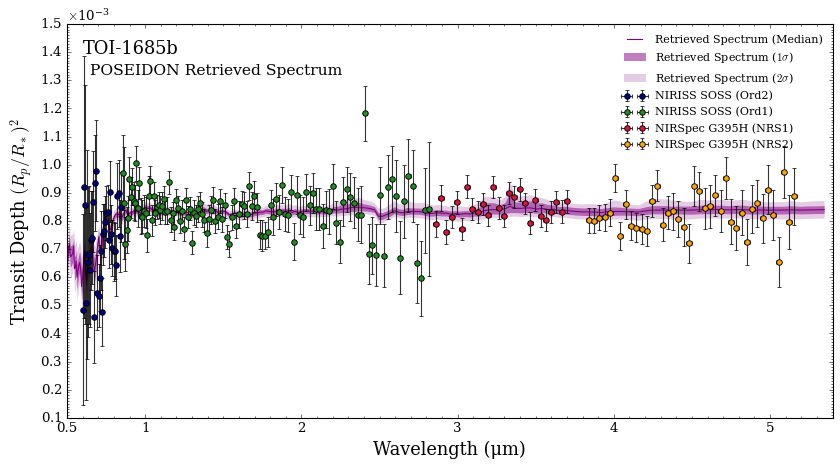

In [3]:
if ('joint' in model_name):
    if('Combined' in model_name):
        data_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta', 'lime', 'cyan', 'gold', 'pink']
        data_labels = ['NIRISS SOSS (Ord2 Visit1)', 'NIRISS SOSS (Ord1 Visit1)',
                    'NIRISS SOSS (Ord2 Visit2)', 'NIRISS SOSS (Ord1 Visit2)',
                    'NIRSpec G395H (NRS1 Visit1)', 'NIRSpec G395H (NRS2 Visit1)',
                    'NIRSpec G395H (NRS1 Visit2)', 'NIRSpec G395H (NRS2 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5, 5, 5, 5, 5]
    else:
        data_colour_list = ['navy', 'forestgreen', 
                            'crimson', 'orange']
        data_labels = ['NIRISS SOSS (Ord2)', 'NIRISS SOSS (Ord1)',
                    'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
elif ('NIRISS' in data_included):
    if('Combined' in model_name):
        data_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta']
        data_labels = ['NIRISS SOSS (Ord2 Visit1)', 'NIRISS SOSS (Ord1 Visit1)',
                    'NIRISS SOSS (Ord2 Visit2)', 'NIRISS SOSS (Ord1 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
    else:
        data_colour_list = ['navy', 'forestgreen']
        data_labels = ['NIRISS SOSS (Ord2)', 'NIRISS SOSS (Ord1)']
        data_marker_list = ['o', 'o']
        data_marker_size_list = [5, 5]
elif ('NIRSpec' in data_included):
    if('Combined' in model_name):
        data_colour_list = ['lime', 'cyan', 'gold', 'pink']
        data_labels = ['NIRSpec G395H (NRS1 Visit1)', 'NIRSpec G395H (NRS2 Visit1)',
                    'NIRSpec G395H (NRS1 Visit2)', 'NIRSpec G395H (NRS2 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
    else:
        data_colour_list = ['crimson', 'orange']
        data_labels = ['NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
        data_marker_list = ['o', 'o']
        data_marker_size_list = [5, 5]


fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100, show_ymodel = False,
                                  plt_label = 'POSEIDON Retrieved Spectrum',
                                  data_colour_list = data_colour_list,
                                  data_labels = data_labels,
                                  data_marker_list = data_marker_list,
                                  data_marker_size_list = data_marker_size_list,
                                  figure_shape = 'wide', wl_axis = 'linear',
                                  wl_min = wl_min, wl_max = wl_max,
                                  #show_data_bin_width = False,
                                  add_retrieved_offsets = True,
                                  model = model,
                                  )

Applied -57.48 ppm offset to offset_1_datasets


FileNotFoundError: ./POSEIDON_output/TOI-1685b/spectra/TOI-1685b_joint_NIRISS_NIRSpec_Offset_Stacked_ExoTEP_R100_spectrum.txt not found.

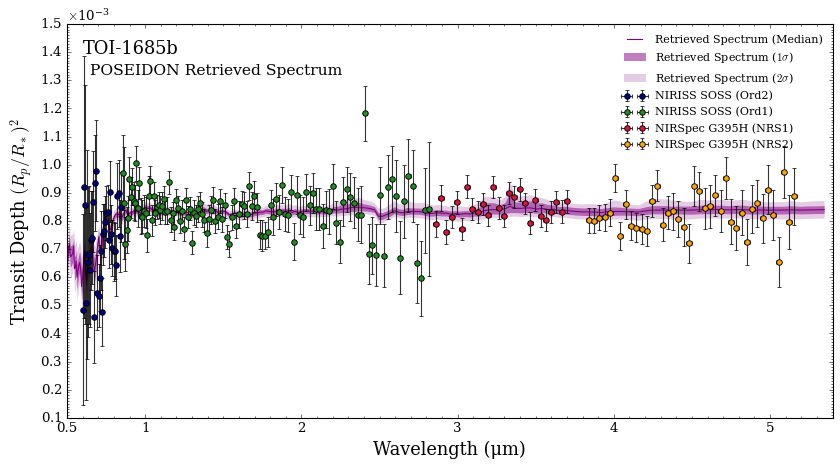

In [5]:
import matplotlib.pyplot as plt

if ('joint' in model_name):
    if('Combined' in model_name):
        data_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta', 'lime', 'cyan', 'gold', 'pink']
        data_labels = ['NIRISS SOSS (Ord2 Visit1)', 'NIRISS SOSS (Ord1 Visit1)',
                    'NIRISS SOSS (Ord2 Visit2)', 'NIRISS SOSS (Ord1 Visit2)',
                    'NIRSpec G395H (NRS1 Visit1)', 'NIRSpec G395H (NRS2 Visit1)',
                    'NIRSpec G395H (NRS1 Visit2)', 'NIRSpec G395H (NRS2 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5, 5, 5, 5, 5]
    else:
        data_colour_list = ['navy', 'forestgreen', 
                            'crimson', 'orange']
        data_labels = ['NIRISS SOSS (Ord2)', 'NIRISS SOSS (Ord1)',
                    'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
elif ('NIRISS' in data_included):
    if('Combined' in model_name):
        data_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta']
        data_labels = ['NIRISS SOSS (Ord2 Visit1)', 'NIRISS SOSS (Ord1 Visit1)',
                    'NIRISS SOSS (Ord2 Visit2)', 'NIRISS SOSS (Ord1 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
    else:
        data_colour_list = ['navy', 'forestgreen']
        data_labels = ['NIRISS SOSS (Ord2)', 'NIRISS SOSS (Ord1)']
        data_marker_list = ['o', 'o']
        data_marker_size_list = [5, 5]
elif ('NIRSpec' in data_included):
    if('Combined' in model_name):
        data_colour_list = ['lime', 'cyan', 'gold', 'pink']
        data_labels = ['NIRSpec G395H (NRS1 Visit1)', 'NIRSpec G395H (NRS2 Visit1)',
                    'NIRSpec G395H (NRS1 Visit2)', 'NIRSpec G395H (NRS2 Visit2)']
        data_marker_list = ['o', 'o', 'o', 'o']
        data_marker_size_list = [5, 5, 5, 5]
    else:
        data_colour_list = ['crimson', 'orange']
        data_labels = ['NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
        data_marker_list = ['o', 'o']
        data_marker_size_list = [5, 5]


fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100, show_ymodel = False,
                                  plt_label = 'POSEIDON Retrieved Spectrum',
                                  data_colour_list = data_colour_list,
                                  data_labels = data_labels,
                                  data_marker_list = data_marker_list,
                                  data_marker_size_list = data_marker_size_list,
                                  figure_shape = 'wide', wl_axis = 'linear',
                                  wl_min = wl_min, wl_max = wl_max,
                                  #show_data_bin_width = False,
                                  add_retrieved_offsets = True,
                                  model = model,
                                  )

# Load the data
filenames = []
filenames.append("./POSEIDON_output/TOI-1685b/spectra/TOI-1685b_joint_NIRISS_NIRSpec_Offset_Stacked_ExoTEP_R100_spectrum.txt")
# filenames.append("./POSEIDON_output/GJ-3090b/spectra/GJ-3090b_multigas_OS_2000_NIRSpec_Stacked_exoTEDRF_R100_spectrum_atm.txt")
# filenames.append("./POSEIDON_output/GJ-3090b/spectra/GJ-3090b_multigas_OS_2000_NIRSpec_Stacked_exoTEDRF_R100_spectrum_atm_os_original.txt")

for i in range(0,len(filenames)):
    datum = np.loadtxt(filenames[i])

    # Extract wavelength and transit depth
    wavelength = datum[:, 0]
    transit_depth = datum[:, 1]  # Convert to ppm

    # Define resolving power
    R = 250

    # Bin the data
    binned_wavelengths = []
    binned_transit_depths = []
    binned_errors = []

    i = 0
    while i < len(wavelength):
        lambda_start = wavelength[i]
        lambda_end = lambda_start + lambda_start / R
        mask = (wavelength >= lambda_start) & (wavelength < lambda_end)

        if np.any(mask):  # Ensure there's data in the bin
            binned_wavelengths.append(np.mean(wavelength[mask]))
            binned_transit_depths.append(np.mean(transit_depth[mask]))
            binned_errors.append(np.std(transit_depth[mask]) / np.sqrt(np.sum(mask)))  # Std. error of mean

        i += np.sum(mask)  # Move to the next bin

    # Convert to numpy arrays
    binned_wavelengths = np.array(binned_wavelengths)
    binned_transit_depths = np.array(binned_transit_depths)
    binned_errors = np.array(binned_errors)
    plt.plot(binned_wavelengths, binned_transit_depths, linestyle="-", c = "indianred", linewidth=2, label=f"Binned (R={R})")


# # Plot the binned spectrum
# plt.figure(figsize=(8, 5))
# # plt.plot(wavelength, transit_depth, marker="o", linestyle="none", alpha=0.3, color="b", label="Original Data")

# # Labels and title
# plt.xlabel("Wavelength (μm)")
# plt.ylabel("Transit Depth (ppm)")
# plt.title("Binned Exoplanet Transmission Spectrum")
# plt.legend()
# plt.grid(True)

# # Show the plot
# plt.show()

No offsets found, plotting data without offsets


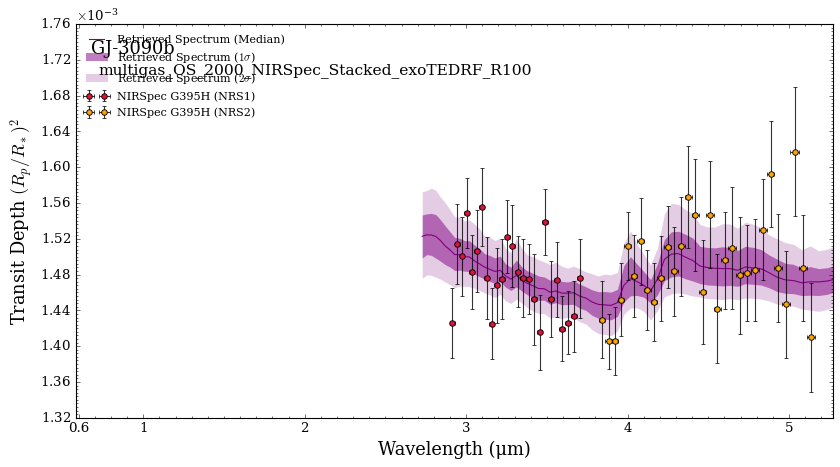

In [ ]:
fig_spec_1 = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                    spectra_high1, spectra_high2, planet_name,
                                    data, R_to_bin = 100, show_ymodel = False,
                                    plt_label = model_name,
                                    colour_list = ['purple'],
                                    data_colour_list = data_colour_list,
                                    data_labels = data_labels,
                                    data_marker_list = data_marker_list,
                                    data_marker_size_list = data_marker_size_list,
                                    figure_shape = 'wide', wl_axis = 'linear',
                                    legend_location = 'best',
                                    wl_min = wl_min, wl_max = wl_max,
                                    # y_min = 4.38e-3, y_max = 5.86e-3,
                                    #show_data_bin_width = False,
                                    #show_data_cap = False,
                                    #data_alpha = 0.6,
                                    save_fig = False,
                                    add_retrieved_offsets = True,
                                    model = model,
                                    #data_edge_width = 1.2,
                                    # text_annotations = ['Cloud', 'Li?', 'CrH?', 'H$_2$O', 
                                    #                     'H$_2$O', 'Cloud', 'H$_2$O', 'Cloud', 
                                    #                     'CO$_2$?'],
                                    # annotation_pos = [(0.67, 5.26e-3), (0.64, 5.14e-3), (0.8, 5.15e-3), (1.08, 5.12e-3), 
                                    #                   (1.35, 5.32e-3), (1.56, 5.07e-3), (1.84, 5.26e-3), (2.18, 5.24e-3),
                                    #                   (2.5, 5.6e-3)],
                                    )

            

#fig_spec_1.savefig('./POSEIDON_output/HAT-P-26b/plots/HAT-P-26b_Amelie_spectrum.png', bbox_inches='tight', dpi=400)
#fig_spec_1.savefig('./POSEIDON_output/HAT-P-26b/plots/HAT-P-26b_Amelie_spectrum_annotated.png', bbox_inches='tight', dpi=400)

# Histogram Plot

Applied -57.48 ppm offset to offset_1_datasets


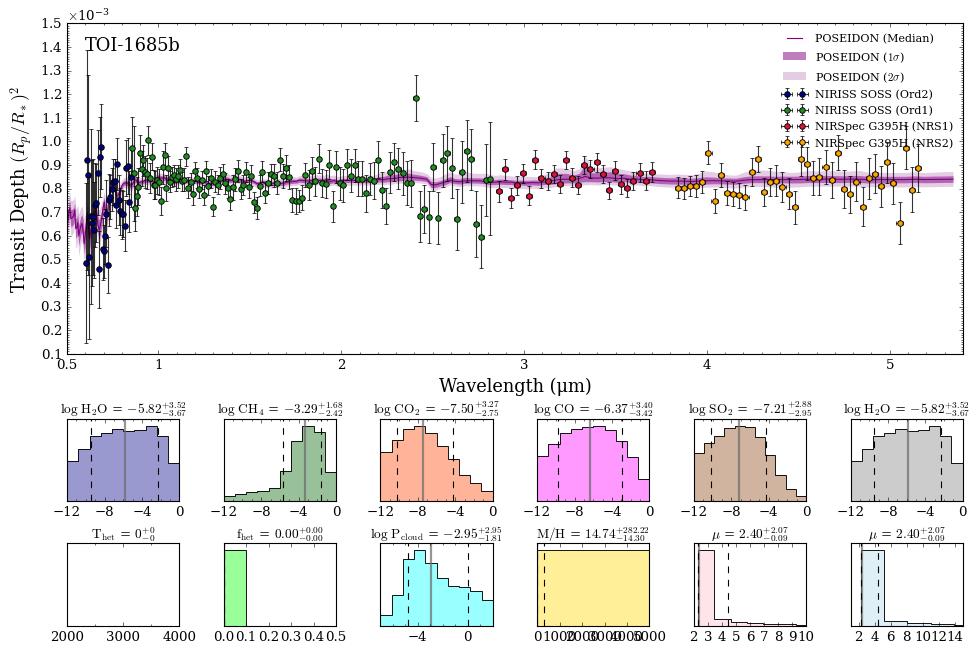

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x800 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt


fig_combined = plt.figure(constrained_layout=True, figsize=(12,8.0))
                          
axd = fig_combined.subplot_mosaic(
    """
    AAAAAA
    AAAAAA
    AAAAAA
    AAAAAA
    abcdef
    ghijkl
    """
)

ax_spectrum = axd["A"]
axes_histograms = [axd["a"], axd["b"], axd["c"], axd["d"], axd["e"], axd["f"],
                   axd["g"], axd["h"], axd["i"], axd["j"], axd["k"], axd["l"]]

_ = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                    spectra_high1, spectra_high2, planet_name,
                                    data, R_to_bin = 100, show_ymodel = False,
                                    plt_label = None,
                                    colour_list = ['purple'],
                                    data_colour_list = data_colour_list,
                                    spectra_labels = ['POSEIDON'],
                                    data_labels = data_labels,
                                    data_marker_list = data_marker_list,
                                    data_marker_size_list =  data_marker_size_list,
                                    figure_shape = 'wide', wl_axis = 'linear',
                                    legend_location = 'upper right',
                                    wl_min = wl_min, wl_max = wl_max,
                                    # y_min = 0, y_max = 4e-3,
                                    # show_data_bin_width = False,
                                    # show_data_cap = False,
                                    # data_alpha = 0.6,
                                    save_fig = False,
                                    # data_edge_width = 1.2,
                                    ax = ax_spectrum,
                                    add_retrieved_offsets = True,
                                    model = model,
                                 #   text_annotations = ['Aerosols?', 'CrH?', 'H$_2$O', 
                                 #                       'H$_2$O', 'Cloud', 'H$_2$O', 'H$_2$O'],
                                 #   annotation_pos = [(0.63, 5.36e-3), (0.8, 5.45e-3), (1.08, 5.20e-3), 
                                 #                     (1.35, 5.38e-3), (1.57, 5.12e-3), (1.84, 5.30e-3), (2.5, 5.52e-3)],
                                    )

models = [model]

_ = plot_histograms(planet, models, plot_parameters = ['log_H2O', 'log_CH4', 'log_CO2', 'log_CO', 'log_SO2', 'log_H2O',
                                                        'T_het', 'f_het', 'log_P_cloud', 'M/H', 'mu', 'mu'],
                    parameter_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta', 'saddlebrown', 'grey', 'brown', 'lime', 'cyan', 'gold', 'pink', 'lightblue'],
                    span = ((-12, 0), (-12, 0), (-12, 0), (-12, 0), (-12, 0), (-12, 0),
                            (2000, 4000), (0, .5), (-7, 2), (0, 5000), (2, 10), (1, 15)),
                    N_bins = [10, 10, 10, 10, 11, 10,
                              10, 10, 10, 50, 50, 20],
                    retrieval_colour_list = ['purple'],
                    axes = axes_histograms, save_fig = False,
                    retrieval_codes = ['POSEIDON'],
                    )

fig_combined.savefig('./POSEIDON_output/TOI-1685b/plots/' + model_name + '_Histogram.pdf', bbox_inches='tight', dpi=800)

# Model Comparison

In [ ]:
model_name_2 = 'flat_OS_2000_' + data_included

stellar_contam = None
if '_OS_' in model_name_2:
    stellar_contam = 'one_spot'
elif '_OSfree_' in model_name_2:
    stellar_contam = 'one_spot_free_log_g'
if '_TS_' in model_name_2:
    stellar_contam = 'two_spots'
elif '_TSfree_' in model_name_2:
    stellar_contam = 'two_spots_free_log_g'

#***** Define model *****#

cloud_model = 'MacMad17'
surface = False
disable_atmosphere = False
if 'flat_' in model_name_2:
    param_species = []
    surface = True
    disable_atmosphere = True

cloud_type = 'deck_haze'
if 'no-haze_' in model_name_2:
    cloud_type = 'deck'

if 'clear_' in model_name_2:
    cloud_model = 'cloud-free'

# Create the model object
model_2 = define_model(model_name_2, bulk_species, param_species, 
                     PT_profile = 'isotherm', cloud_model = cloud_model,
                     cloud_type = cloud_type, cloud_dim = 1,
                     radius_unit = 'R_E', surface = surface,
                     disable_atmosphere = disable_atmosphere,
                     stellar_contam = stellar_contam, 
                     offsets_applied = 'single_dataset'
                     )

# Create composite spectra objects for plotting
spectra_median_2 = []
spectra_low2_2 = []
spectra_low1_2 = []
spectra_high1_2 = []
spectra_high2_2 = []

# Read retrieved spectrum confidence regions
wl, spec_low2_2, spec_low1_2, spec_median_2, \
spec_high1_2, spec_high2_2 = read_retrieved_spectrum(planet_name, model_name_2)

In [10]:
Bayesian_model_comparison(planet_name, model, model_2)

Bayesian evidences:

Model multigas_OS_2000_NIRSpec_Stacked_exoTEDRF_R100: ln Z = 467.53 +/- 0.06
Model flat_OS_2000_NIRSpec_Stacked_exoTEDRF_R100: ln Z = 466.51 +/- 0.05

Bayes factor:

B = 2.79e+00
ln B = 1.03

'Equivalent' detection significance:

2.0 σ



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices